In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import stan
from pathlib import Path

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load NND metrics
df = pd.read_csv('processed_data/nnd_ALL.csv')

## Factor ordering + labels
lek_order = ['TalChhapar_TC', 'Velavadar_LEK1', 'Velavadar_LEK2']
lek_labels = {'TalChhapar_TC': 'Tal Chhapar', 'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2'}

df['lek_id'] = (pd.Categorical(df['lek_id'], categories=lek_order, ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels = df['lek_id'].cat.categories.tolist()

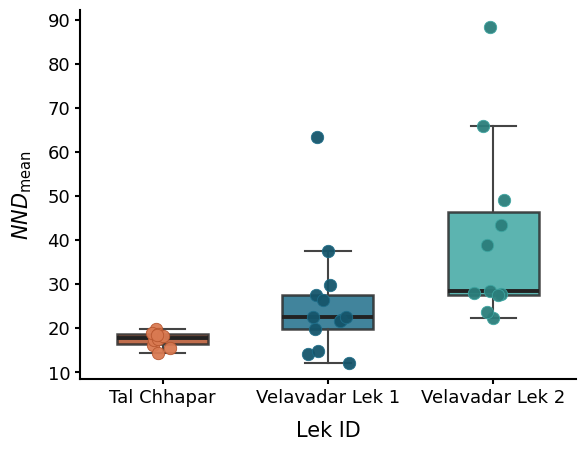

In [5]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_mean'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_mean'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{mean}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'summary_nnd_mean.png', dpi=300, bbox_inches='tight')

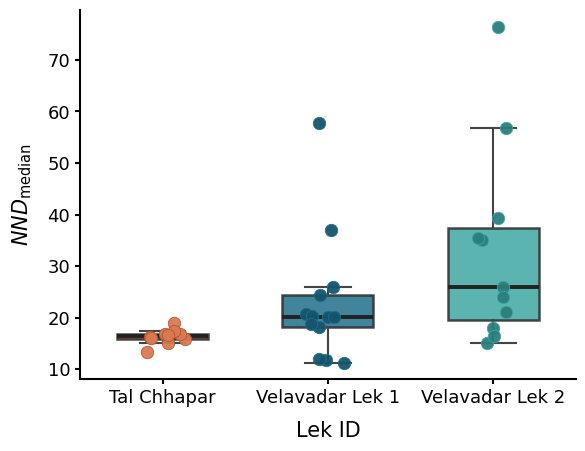

In [6]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_median'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_median'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{median}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'summary_nnd_median.png', dpi=300, bbox_inches='tight')

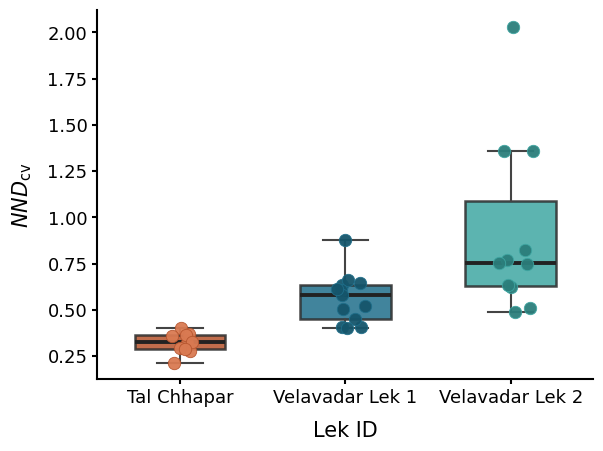

In [7]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_cv'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_cv'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{cv}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'summary_nnd_cv.png', dpi=300, bbox_inches='tight')

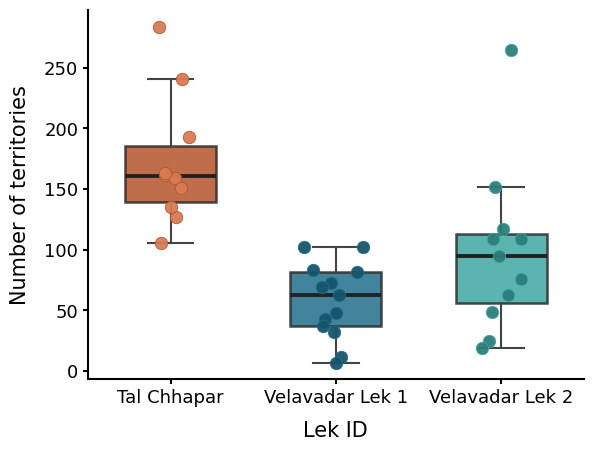

In [8]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_count'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_count'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel('Number of territories', fontsize=15, labelpad=10)


plt.savefig(out_dir/'summary_territory_count.png', dpi=300, bbox_inches='tight')

In [9]:
df['date'] = pd.to_datetime(df['date'])

df = df[['lek_id', 'date', 'nnd_median', 'nnd_cv', 'nnd_count']].dropna().copy()
df = df.sort_values(['lek_id', 'date']).reset_index(drop=True)

## Serialise and centre the date / time
t0 = df['date'].min()
df['t_years'] = (df['date'] - t0).dt.days / 365.25
df['t_centred'] = df['t_years'] - df['t_years'].mean()

## Log transform nnd columns to construct a log-normal model
df['log_nnd_median'] = np.log(df['nnd_median'].astype(float))
df['log_nnd_cv'] = np.log(df['nnd_cv'].astype(float))
df['log_nnd_count'] = np.log(df['nnd_count'].astype(float))

## Encode lek ID in a numerical variable
lek_levels = sorted(df['lek_id'].unique())
lek_map = {lek: i + 1 for i, lek in enumerate(lek_levels)}
df['site_id'] = df['lek_id'].map(lek_map).astype(int)

In [10]:
## Specify time axis
t_min, t_max = float(df['t_centred'].min()), float(df['t_centred'].max())
t_grid = np.linspace(t_min, t_max, 200)
t_years = t_grid + df['t_years'].mean()
date_grid = t0 + pd.to_timedelta(t_years * 365.25, unit='D')

### Model the **total effect** of site-ID and time on the nearest-neighbour distance

In [11]:
## 1) Total effect of time on the median NND (per site)
nnd_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] y;
}

parameters {
  real mu_alpha;
  real mu_beta;

  vector[n_sites] alpha_raw;
  vector[n_sites] beta_raw;

  real<lower=0> tau_alpha;
  real<lower=0> tau_beta;

  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] alpha = mu_alpha + tau_alpha * alpha_raw;
  vector[n_sites] beta  = mu_beta + tau_beta  * beta_raw;
}

model {
  mu_alpha ~ normal(0, 1);
  mu_beta ~ normal(0, 1);

  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  tau_alpha ~ exponential(1);
  tau_beta ~ exponential(1);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(alpha[site_id[n]] + beta[site_id[n]] * t[n], sigma);
  }
}
"""

In [12]:
nnd_data = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'y': df['log_nnd_median'].astype(float).to_numpy()
}

posterior = stan.build(nnd_mod, data=nnd_data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   2% (200/8000)
Sampling:   8% (600/8000)
Sampling:  16% (1300/8000)
Sampling:  41% (3300/8000)
Sampling:  64% (5100/8000)
Sampling:  84% (6700/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 4.3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.43 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 3.7e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.37 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/tmp/httpstan_c0baluue/model_nkllen6v.stan', line 42, column 4 to column 70)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance

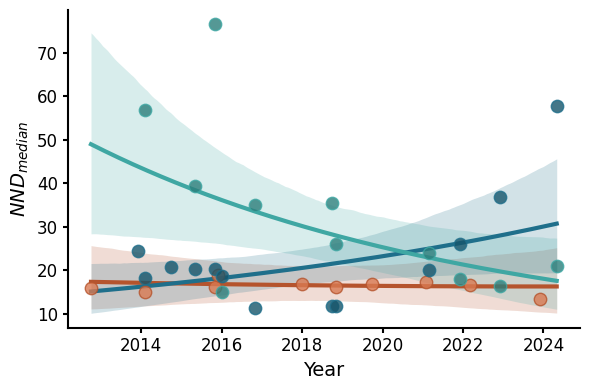

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:]
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot
    ax.scatter(df_lek['date'], df_lek['nnd_median'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{median}$', fontsize=14)

    plt.tight_layout()
plt.savefig(out_dir/'mod_nnd_median.png', dpi=300, bbox_inches='tight')

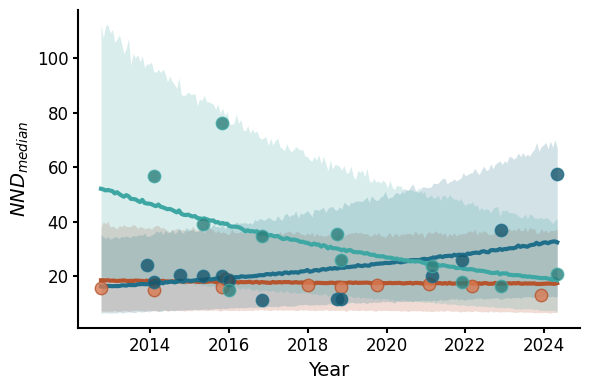

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Posterior predictive check
    mu_post = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:]
    sigma_post = fit['sigma'].reshape(-1,1)
    
    y_post_rep = np.exp(np.random.normal(mu_post, sigma_post))
    y_post_mean = np.mean(y_post_rep, axis=0)
    y_post_lower,y_post_upper = np.quantile(y_post_rep, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_post_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_post_lower, y_post_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot
    ax.scatter(df_lek['date'], df_lek['nnd_median'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{median}$', fontsize=14)

    plt.tight_layout()
plt.savefig(out_dir/'mod_post_nnd_median.png', dpi=300, bbox_inches='tight')

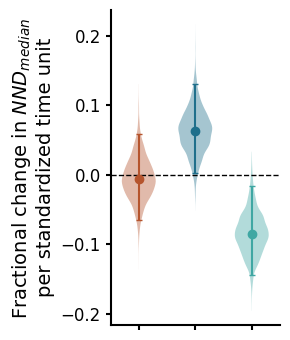

In [15]:
fig, ax = plt.subplots(figsize=(3, 3.5))

## x-positions for categorical variables
x_pos = np.arange(len(lek_labels))

for i,lek in enumerate(lek_labels):
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute causal effect distribution (fractional yearly change)
    yearly_factor = np.exp(fit['beta'][site_id, :])
    samples = yearly_factor - 1

    # Violin plot
    parts = ax.violinplot(samples, positions=[x_pos[i]], widths=0.6, showmeans=False, showmedians=False, showextrema=False)

    for pc in parts['bodies']:
        pc.set_facecolor(fill_cols.get(lek))
        pc.set_edgecolor('none')
        pc.set_alpha(0.4)

    # Overlay median + 95% interval
    median = np.median(samples)
    lower, upper = np.quantile(samples, [0.025, 0.975])

    ax.errorbar(x_pos[i], median, yerr=[[median-lower], [upper-median]], fmt='o', color=fill_cols.get(lek), markersize=6, capsize=2, zorder=3)

ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_xlim(-0.5, len(lek_labels) - 0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([])

ax.set_ylabel('Fractional change in $NND_{median}$ \nper year', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'mod_causal_nnd_median.png', dpi=300, bbox_inches='tight')

In [16]:
## 2) Total effect of time on the CV of the NND (per site)
nnd_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] y;
}

parameters {
  real mu_alpha;
  real mu_beta;

  vector[n_sites] alpha_raw;
  vector[n_sites] beta_raw;

  real<lower=0> tau_alpha;
  real<lower=0> tau_beta;
  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] alpha = mu_alpha + tau_alpha * alpha_raw;
  vector[n_sites] beta  = mu_beta + tau_beta  * beta_raw;
}

model {
  mu_alpha ~ normal(0, 1);
  mu_beta ~ normal(0, 1);

  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  tau_alpha ~ exponential(1);
  tau_beta ~ exponential(1);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(alpha[site_id[n]] + beta[site_id[n]] * t[n], sigma);
  }
}
"""

In [17]:
nnd_data = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'y': df['log_nnd_cv'].astype(float).to_numpy()
}

posterior = stan.build(nnd_mod, data=nnd_data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: 0.1s
Building: 0.2s
Building: 0.3s
Building: 0.4s
Building: 0.5s
Building: 0.6s
Building: 0.7s
Building: 0.9s
Building: 1.0s
Building: 1.1s
Building: 1.2s
Building: 1.3s
Building: 1.4s
Building: 1.5s
Building: 1.6s
Building: 1.7s
Building: 1.8s
Building: 1.9s
Building: 2.0s
Building: 2.1s
Building: 2.2s
Building: 2.3s
Building: 2.4s
Building: 2.5s
Building: 2.6s
Building: 2.7s
Building: 2.8s
Building: 2.9s
Building: 3.0s
Building: 3.1s
Building: 3.3s
Building: 3.4s
Building: 3.5s
Building: 3.6s
Building: 3.7s
Building: 3.8s
Building: 3.9s
Building: 4.0s
Building: 4.1s
Building: 4.2s
Building: 4.3s
Building: 4.4s
Building: 4.5s
Building: 4.6s
Building: 4.7s
Building: 4.8s
Building: 4.9s
Building: 5.0s
Building: 5.1s
Building: 5.2s
Building: 5.3s
Building: 5.5s
Building: 5.6s
Building: 5.7s
Building: 5.8s
Building: 5.9s
Building: 6.0s
Building: 6.1s
Building: 6.2s
Building: 6.3s
Building: 6.4s
Building: 6.5s
Building: 6.6s
Building: 6.7s
Building: 6.8s
Building: 6.9s
Building: 

In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_ccdf_log.hpp:5,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob.hpp:331,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math.hpp:19,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/model/model_header.hpp:4,
                 from /home/vivek/.cache/httpstan/4.13.0/models/2v5prvv3/model_2v5prvv3.cpp:2:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_lccdf.hpp: In function ‘stan::return_typ

Building: 10.6s
Building: 10.7s
Building: 10.8s
Building: 10.9s
Building: 11.0s
Building: 11.1s
Building: 11.2s
Building: 11.3s
Building: 11.4s
Building: 11.5s
Building: 11.6s
Building: 11.7s
Building: 11.9s
Building: 12.0s


In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/concurrent_unordered_map.h:26,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core/profiling.hpp:10,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core.hpp:53,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:10:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/internal/_concurrent_unordered_impl.h: In instantiation of ‘void tbb::interface5::internal::concurrent_unordered_base<Traits>::internal_init() [with Traits = tbb::interface5::concurrent_unordered_map_traits<std::pair<std::basic_string<char>, std::thread::id>, stan::math::profile_info, tbb::interface5::internal::hash_compare<std::pair<std::basic_string<char>, std::thread::id>, stan::math::internal::hash_p

Building: 12.1s
Building: 12.2s
Building: 12.3s
Building: 12.4s
Building: 12.5s
Building: 12.6s
Building: 12.7s
Building: 12.8s
Building: 12.9s
Building: 13.0s
Building: 13.1s
Building: 13.2s
Building: 13.3s
Building: 13.4s
Building: 13.5s
Building: 13.6s
Building: 13.7s
Building: 13.8s
Building: 13.9s
Building: 14.1s
Building: 14.2s
Building: 14.3s
Building: 14.4s
Building: 14.5s
Building: 14.6s
Building: 14.7s
Building: 14.8s
Building: 14.9s
Building: 15.0s
Building: 15.1s
Building: 15.2s
Building: 15.3s
Building: 15.4s
Building: 15.5s
Building: 15.6s
Building: 15.7s
Building: 15.8s
Building: 15.9s
Building: 16.0s
Building: 16.1s
Building: 16.2s
Building: 16.3s
Building: 16.4s
Building: 16.6s
Building: 16.7s
Building: 16.8s
Building: 16.9s
Building: 17.0s
Building: 17.1s
Building: 17.2s
Building: 17.3s
Building: 17.4s
Building: 17.5s
Building: 17.6s
Building: 17.7s
Building: 17.8s
Building: 17.9s
Building: 18.0s
Building: 18.1s
Building: 18.2s
Building: 18.3s
Building: 18.4s
Building

Building: 23.5s, done.
Sampling:   0%
Sampling:   5% (400/8000)
Sampling:  30% (2400/8000)
Sampling:  55% (4400/8000)
Sampling:  80% (6400/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 2.4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.24 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.2 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.25 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.23 seconds.
  Adjust your expectations accordingly!


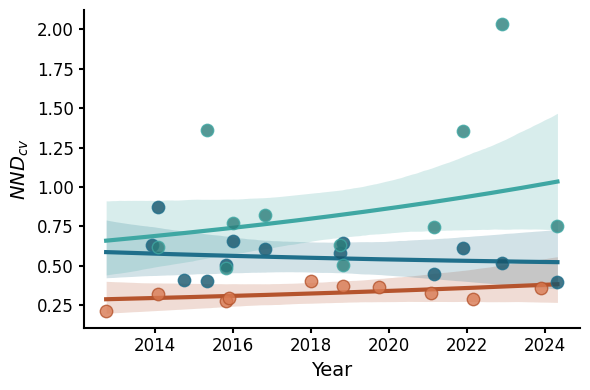

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:]
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot
    ax.scatter(df_lek['date'], df_lek['nnd_cv'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{cv}$', fontsize=14)

    plt.tight_layout()
plt.savefig(out_dir/'mod_nnd_cv.png', dpi=300, bbox_inches='tight')

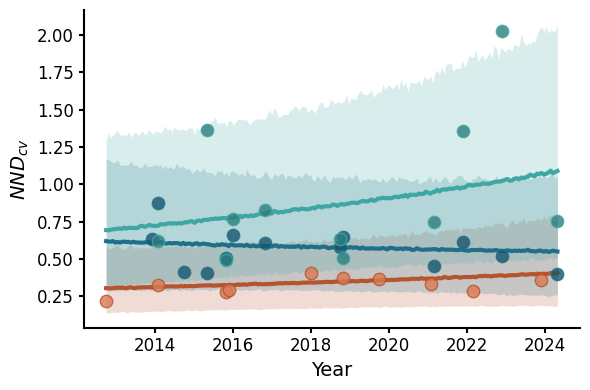

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Posterior predictive check
    mu_post = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:]
    sigma_post = fit['sigma'].reshape(-1,1)
    
    y_post_rep = np.exp(np.random.normal(mu_post, sigma_post))
    y_post_mean = np.mean(y_post_rep, axis=0)
    y_post_lower,y_post_upper = np.quantile(y_post_rep, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_post_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_post_lower, y_post_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot
    ax.scatter(df_lek['date'], df_lek['nnd_cv'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{cv}$', fontsize=14)

    plt.tight_layout()
plt.savefig(out_dir/'mod_post_nnd_cv.png', dpi=300, bbox_inches='tight')

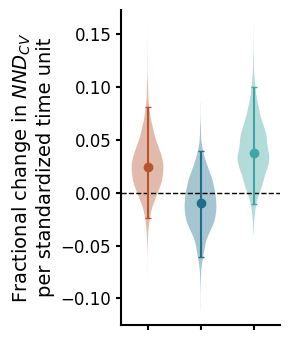

In [20]:
fig, ax = plt.subplots(figsize=(3, 3.5))

## x-positions for categorical variables
x_pos = np.arange(len(lek_labels))

for i,lek in enumerate(lek_labels):
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute causal effect distribution (fractional yearly change)
    yearly_factor = np.exp(fit['beta'][site_id, :])
    samples = yearly_factor - 1

    # Violin plot
    parts = ax.violinplot(samples, positions=[x_pos[i]], widths=0.6, showmeans=False, showmedians=False, showextrema=False)

    for pc in parts['bodies']:
        pc.set_facecolor(fill_cols.get(lek))
        pc.set_edgecolor('none')
        pc.set_alpha(0.4)

    # Overlay median + 95% interval
    median = np.median(samples)
    lower, upper = np.quantile(samples, [0.025, 0.975])

    ax.errorbar(x_pos[i], median, yerr=[[median-lower], [upper-median]], fmt='o', color=fill_cols.get(lek), markersize=6, capsize=2, zorder=3)

ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_xlim(-0.5, len(lek_labels) - 0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([])

ax.set_ylabel('Fractional change in $NND_{CV}$ \nper year', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'mod_causal_nnd_cv.png', dpi=300, bbox_inches='tight')

### Model the **total effect** of the number of male territories / the **direct effect** of site-ID and time on the nearest-neighbour distance 

In [21]:
## 1) Total effect of the number of male territories on the median NND
## The same model doubles as the direct effect of time on the median NND (per site)
local_repulsion_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] n_territories;
  vector[n_points] y;
}

parameters {
  real mu_alpha;
  real mu_beta;
  real gamma;

  vector[n_sites] alpha_raw;
  vector[n_sites] beta_raw;

  real<lower=0> tau_alpha;
  real<lower=0> tau_beta;

  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] alpha = mu_alpha + tau_alpha * alpha_raw;
  vector[n_sites] beta  = mu_beta + tau_beta  * beta_raw;
}

model {
  mu_alpha ~ normal(0, 1);
  mu_beta ~ normal(0, 1);
  gamma ~ normal(0, 1);

  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  tau_alpha ~ exponential(1);
  tau_beta ~ exponential(1);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(alpha[site_id[n]] + beta[site_id[n]] * t[n] + gamma * n_territories[n], sigma);
  }
}
"""

In [22]:
data_repulsion = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'n_territories': df['log_nnd_count'].astype(float).to_numpy(),
    'y': df['log_nnd_median'].astype(float).to_numpy()
}

posterior = stan.build(local_repulsion_mod, data=data_repulsion)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: 0.1s
Building: 0.2s
Building: 0.3s
Building: 0.4s
Building: 0.5s
Building: 0.6s
Building: 0.7s
Building: 0.8s
Building: 0.9s
Building: 1.0s
Building: 1.1s
Building: 1.2s
Building: 1.3s
Building: 1.4s
Building: 1.6s
Building: 1.7s
Building: 1.8s
Building: 1.9s
Building: 2.0s
Building: 2.1s
Building: 2.2s
Building: 2.3s
Building: 2.4s
Building: 2.5s
Building: 2.6s
Building: 2.7s
Building: 2.8s
Building: 2.9s
Building: 3.0s
Building: 3.1s
Building: 3.2s
Building: 3.3s
Building: 3.4s
Building: 3.5s
Building: 3.6s
Building: 3.7s
Building: 3.8s
Building: 3.9s
Building: 4.0s
Building: 4.1s
Building: 4.2s
Building: 4.4s
Building: 4.5s
Building: 4.6s
Building: 4.7s
Building: 4.8s
Building: 4.9s
Building: 5.0s
Building: 5.1s
Building: 5.2s
Building: 5.3s
Building: 5.4s
Building: 5.5s
Building: 5.6s
Building: 5.7s
Building: 5.8s
Building: 5.9s
Building: 6.0s
Building: 6.1s
Building: 6.2s
Building: 6.3s
Building: 6.4s
Building: 6.5s


In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_ccdf_log.hpp:5,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob.hpp:331,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math.hpp:19,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/model/model_header.hpp:4,
                 from /home/vivek/.cache/httpstan/4.13.0/models/h6soso3p/model_h6soso3p.cpp:2:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_lccdf.hpp: In function ‘stan::return_typ

Building: 6.6s
Building: 6.7s
Building: 6.8s
Building: 6.9s
Building: 7.0s
Building: 7.1s
Building: 7.2s
Building: 7.4s


In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/concurrent_unordered_map.h:26,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core/profiling.hpp:10,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core.hpp:53,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:10:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/internal/_concurrent_unordered_impl.h: In instantiation of ‘void tbb::interface5::internal::concurrent_unordered_base<Traits>::internal_init() [with Traits = tbb::interface5::concurrent_unordered_map_traits<std::pair<std::basic_string<char>, std::thread::id>, stan::math::profile_info, tbb::interface5::internal::hash_compare<std::pair<std::basic_string<char>, std::thread::id>, stan::math::internal::hash_p

Building: 7.5s
Building: 7.6s
Building: 7.7s
Building: 7.8s
Building: 7.9s
Building: 8.0s
Building: 8.1s
Building: 8.2s
Building: 8.3s
Building: 8.4s
Building: 8.5s
Building: 8.6s
Building: 8.7s
Building: 8.8s
Building: 8.9s
Building: 9.0s
Building: 9.1s
Building: 9.2s
Building: 9.3s
Building: 9.4s
Building: 9.5s
Building: 9.6s
Building: 9.7s
Building: 9.9s
Building: 10.0s
Building: 10.1s
Building: 10.2s
Building: 10.3s
Building: 10.4s
Building: 10.5s
Building: 10.6s
Building: 10.7s
Building: 10.8s
Building: 10.9s
Building: 11.0s
Building: 11.1s
Building: 11.2s
Building: 11.3s
Building: 11.4s
Building: 11.5s
Building: 11.6s
Building: 11.7s
Building: 11.8s
Building: 11.9s
Building: 12.0s
Building: 12.1s
Building: 12.2s
Building: 12.3s
Building: 12.4s
Building: 12.5s
Building: 12.7s
Building: 12.8s
Building: 12.9s
Building: 13.0s
Building: 13.1s
Building: 13.2s
Building: 13.3s
Building: 13.4s
Building: 13.5s
Building: 13.6s
Building: 13.7s
Building: 13.8s
Building: 13.9s
Building: 14.0s


Building: 17.9s, done.
Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   1% (101/8000)
Sampling:   3% (201/8000)
Sampling:   4% (301/8000)
Sampling:   9% (700/8000)
Sampling:  11% (900/8000)
Sampling:  15% (1200/8000)
Sampling:  19% (1500/8000)
Sampling:  25% (2000/8000)
Sampling:  30% (2400/8000)
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x764a92e13840> is already entered
Sampling:  50% (4000/8000)
Sampling:  70% (5600/8000)
Sampling:  84% (6700/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 1.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.19 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.6e-05 s

/tmp/ipykernel_2337433/2953488246.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()
Task was destroyed but it is pending!
task: <Task pending name='Task-188' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/vivek/Documents/.pystan/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-190' coro=<Kernel.shell_main() running at /home/vivek/Documents/.pystan/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/vivek/Documents/.pystan/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/matplotlib/cbook.py:302: RuntimeWarning: 

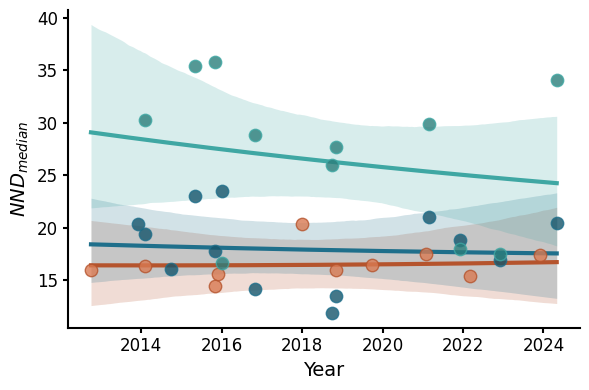

In [23]:
## Fix the number of territories for each lek to median to plot the effect of time on NND
fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()

## Plot the change in NND with time while controlling for the number of territories
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]
    logN0 = fix_logN[lek]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:] + fit['gamma'].reshape(-1,1) * logN0
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot (logNND_adjusted = logNND_observed + gamma * (logN_0 - logN_obs))
    df_lek['nnd_median_adj'] = np.exp(df_lek['log_nnd_median'] + fit['gamma'].mean() * (logN0 - df_lek['log_nnd_count']))
    ax.scatter(df_lek['date'], df_lek['nnd_median_adj'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{median}$', fontsize=14)

    plt.tight_layout()
plt.savefig(out_dir/'mod_nnd_median_adj.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_2337433/3402063530.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()


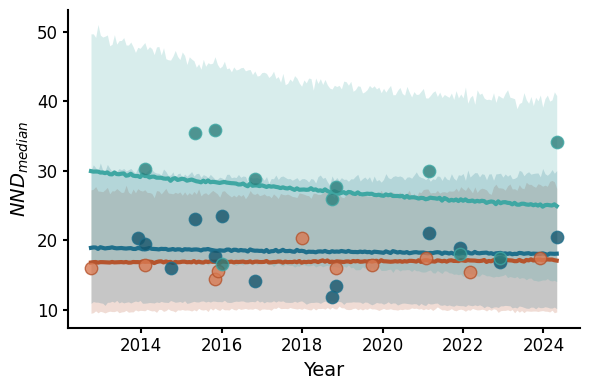

In [24]:
## Fix the number of territories for each lek to median to plot the effect of time on NND
fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()

## Plot the change in NND with time while controlling for the number of territories
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]
    logN0 = fix_logN[lek]

    # Posterior predictive check
    mu_post = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:] + fit['gamma'].reshape(-1,1) * logN0
    sigma_post = fit['sigma'].reshape(-1,1)
    
    y_post_rep = np.exp(np.random.normal(mu_post, sigma_post))
    y_post_mean = np.mean(y_post_rep, axis=0)
    y_post_lower,y_post_upper = np.quantile(y_post_rep, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_post_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_post_lower, y_post_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot (logNND_adjusted = logNND_observed + gamma * (logN_0 - logN_obs))
    df_lek['nnd_median_adj'] = np.exp(df_lek['log_nnd_median'] + fit['gamma'].mean() * (logN0 - df_lek['log_nnd_count']))
    ax.scatter(df_lek['date'], df_lek['nnd_median_adj'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{median}$', fontsize=14)

    plt.tight_layout()
plt.savefig(out_dir/'mod_post_nnd_median_adj.png', dpi=300, bbox_inches='tight')

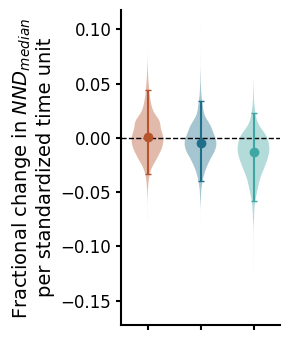

In [25]:
fig, ax = plt.subplots(figsize=(3, 3.5))

## x-positions for categorical variables
x_pos = np.arange(len(lek_labels))

for i,lek in enumerate(lek_labels):
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute causal effect distribution (fractional yearly change)
    yearly_factor = np.exp(fit['beta'][site_id, :])
    samples = yearly_factor - 1

    # Violin plot
    parts = ax.violinplot(samples, positions=[x_pos[i]], widths=0.6, showmeans=False, showmedians=False, showextrema=False)

    for pc in parts['bodies']:
        pc.set_facecolor(fill_cols.get(lek))
        pc.set_edgecolor('none')
        pc.set_alpha(0.4)

    # Overlay median + 95% interval
    median = np.median(samples)
    lower, upper = np.quantile(samples, [0.025, 0.975])

    ax.errorbar(x_pos[i], median, yerr=[[median-lower], [upper-median]], fmt='o', color=fill_cols.get(lek), markersize=6, capsize=2, zorder=3)

ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_xlim(-0.5, len(lek_labels) - 0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([])

ax.set_ylabel('Fractional change in $NND_{median}$ \nper year', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'mod_causal_nnd_median_adj.png', dpi=300, bbox_inches='tight')

In [26]:
## Specify n_territories axis
N_min, N_max = int(df['nnd_count'].min()), int(df['nnd_count'].max())
N_grid = np.linspace(N_min, N_max, 200)
logN_grid = np.log(N_grid)

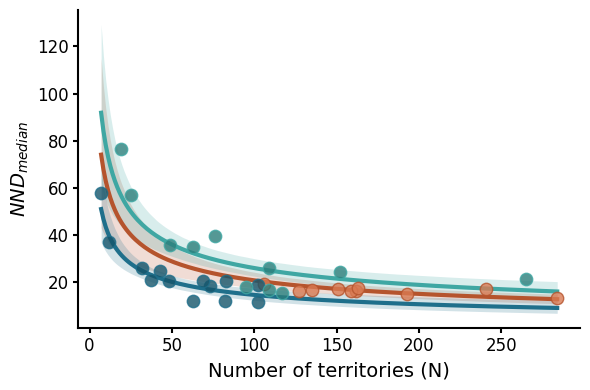

In [27]:
## Plot the effect of the number of territories on NND while controlling for temporal patterns
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id, :].reshape(-1, 1) + fit['gamma'].reshape(-1, 1) * logN_grid.reshape(1, -1)
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(N_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(N_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Overlay observed points (raw relationship, not adjusted)
    ax.scatter(df_lek['nnd_count'], df_lek['nnd_median'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

# Cosmetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Number of territories (N)', fontsize=14)
ax.set_ylabel('$NND_{median}$', fontsize=14)

plt.tight_layout()
plt.savefig(out_dir/'mod_nnd_median_nT.png', dpi=300, bbox_inches='tight')

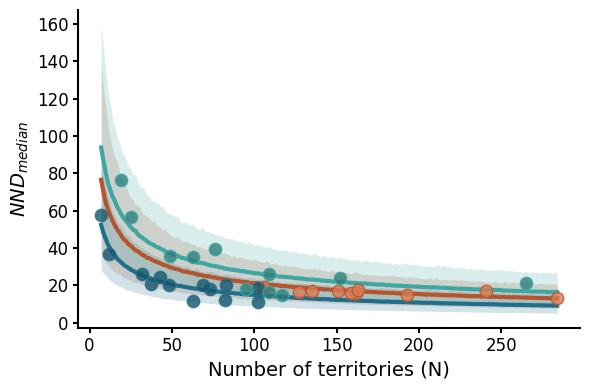

In [28]:
## Plot the effect of the number of territories on NND while controlling for temporal patterns
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Posterior predictive check
    mu_post = fit['alpha'][site_id, :].reshape(-1, 1) + fit['gamma'].reshape(-1, 1) * logN_grid.reshape(1, -1)
    sigma_post = fit['sigma'].reshape(-1,1)
    
    y_post_rep = np.exp(np.random.normal(mu_post,sigma_post))
    y_post_mean = np.mean(y_post_rep, axis=0)
    y_post_lower,y_post_upper = np.quantile(y_post_rep, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(N_grid, y_post_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(N_grid, y_post_lower, y_post_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Overlay observed points (raw relationship, not adjusted)
    ax.scatter(df_lek['nnd_count'], df_lek['nnd_median'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

# Cosmetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Number of territories (N)', fontsize=14)
ax.set_ylabel('$NND_{median}$', fontsize=14)

plt.tight_layout()
plt.savefig(out_dir/'mod_post_nnd_median_nT.png', dpi=300, bbox_inches='tight')

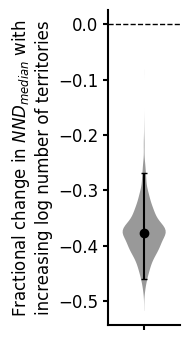

In [29]:
fig, ax = plt.subplots(figsize=(2, 3.5))

# Compute causal effect distribution (fractional yearly change)
yearly_factor = np.exp(fit['gamma'][0, :])
samples = yearly_factor - 1

# Violin plot
parts = ax.violinplot(samples, widths=0.6, showmeans=False, showmedians=False, showextrema=False)

for pc in parts['bodies']:
    pc.set_facecolor('black')
    pc.set_edgecolor('none')
    pc.set_alpha(0.4)

# Overlay median + 95% interval
median = np.median(samples)
lower, upper = np.quantile(samples, [0.025, 0.975])

ax.errorbar(1, median, yerr=[[median-lower], [upper-median]], fmt='o', color='black', markersize=6, capsize=2, zorder=3)

ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_xlim(0.5, 1 + 0.5)
ax.set_xticks([1])
ax.set_xticklabels([])

ax.set_ylabel('Fractional change in $NND_{median}$ with \nincreasing log number of territories', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'mod_causal_nnd_median_nT.png', dpi=300, bbox_inches='tight')

In [30]:
## 2) Total effect of the number of male territories on the CV of the NND
## The same model doubles as the direct effect of time on the CV of the NND (per site)
local_repulsion_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] n_territories;
  vector[n_points] y;
}

parameters {
  real mu_alpha;
  real mu_beta;
  real gamma;

  vector[n_sites] alpha_raw;
  vector[n_sites] beta_raw;

  real<lower=0> tau_alpha;
  real<lower=0> tau_beta;

  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] alpha = mu_alpha + tau_alpha * alpha_raw;
  vector[n_sites] beta  = mu_beta + tau_beta  * beta_raw;
}

model {
  mu_alpha ~ normal(0, 1);
  mu_beta ~ normal(0, 1);
  gamma ~ normal(0, 1);

  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  tau_alpha ~ exponential(1);
  tau_beta ~ exponential(1);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(alpha[site_id[n]] + beta[site_id[n]] * t[n] + gamma * n_territories[n], sigma);
  }
}
"""

In [31]:
data_repulsion = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'n_territories': df['log_nnd_count'].astype(float).to_numpy(),
    'y': df['log_nnd_cv'].astype(float).to_numpy()
}

posterior = stan.build(local_repulsion_mod, data=data_repulsion)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   1% (100/8000)
Sampling:   5% (400/8000)
Sampling:  10% (800/8000)
Sampling:  18% (1400/8000)
Sampling:  41% (3300/8000)
Sampling:  62% (5000/8000)
Sampling:  82% (6600/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.3 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 3.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.38 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.28 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 3.1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.31 seconds.
  Adjust your expectations accordingly!


/tmp/ipykernel_2337433/2452304994.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()


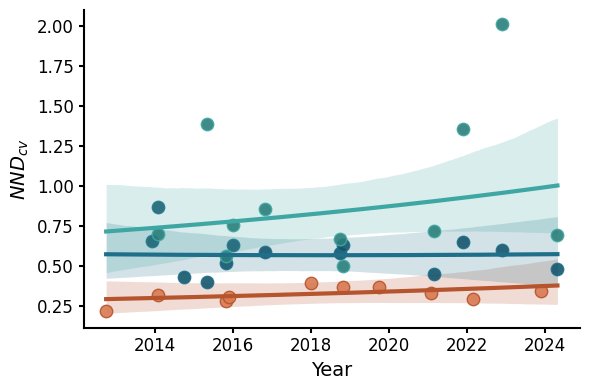

In [32]:
## Fix the number of territories for each lek to median to plot the effect of time on NND
fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()

## Plot the change in NND CV with time while controlling for the number of territories
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]
    logN0 = fix_logN[lek]

    # Compute posterior mean log(NND_cv) and back-transform to return to original units 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:] + fit['gamma'].reshape(-1,1) * logN0
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot (logNND_adjusted = logNND_observed + gamma * (logN_0 - logN_obs))
    df_lek['nnd_cv_adj'] = np.exp(df_lek['log_nnd_cv'] + fit['gamma'].mean() * (logN0 - df_lek['log_nnd_count']))
    ax.scatter(df_lek['date'], df_lek['nnd_cv_adj'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.9, zorder=1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{cv}$', fontsize=14)

    plt.tight_layout()
plt.savefig(out_dir/'mod_nnd_cv_adj.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_2337433/263712649.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()


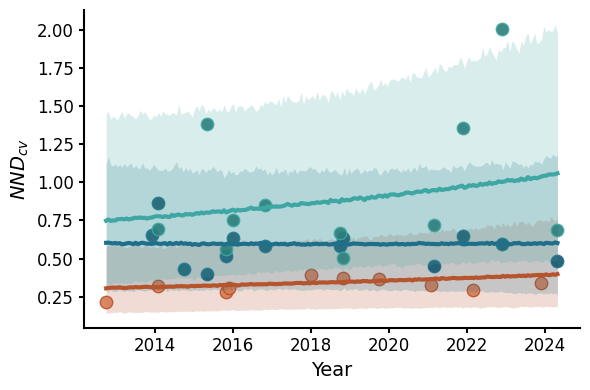

In [33]:
## Fix the number of territories for each lek to median to plot the effect of time on NND
fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()

## Plot the change in NND with time while controlling for the number of territories
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]
    logN0 = fix_logN[lek]

    # Posterior predictive check
    mu_post = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:] + fit['gamma'].reshape(-1,1) * logN0
    sigma_post = fit['sigma'].reshape(-1,1)
    
    y_post_rep = np.exp(np.random.normal(mu_post, sigma_post))
    y_post_mean = np.mean(y_post_rep, axis=0)
    y_post_lower,y_post_upper = np.quantile(y_post_rep, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_post_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_post_lower, y_post_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot (logNND_adjusted = logNND_observed + gamma * (logN_0 - logN_obs))
    df_lek['nnd_cv_adj'] = np.exp(df_lek['log_nnd_cv'] + fit['gamma'].mean() * (logN0 - df_lek['log_nnd_count']))
    ax.scatter(df_lek['date'], df_lek['nnd_cv_adj'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.9, zorder=1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('$NND_{cv}$', fontsize=14)

    plt.tight_layout()
plt.savefig(out_dir/'mod_post_nnd_cv_adj.png', dpi=300, bbox_inches='tight')

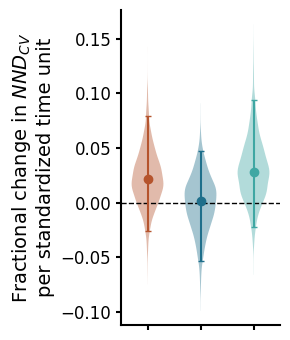

In [34]:
fig, ax = plt.subplots(figsize=(3, 3.5))

## x-positions for categorical variables
x_pos = np.arange(len(lek_labels))

for i,lek in enumerate(lek_labels):
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute causal effect distribution (fractional yearly change)
    yearly_factor = np.exp(fit['beta'][site_id, :])
    samples = yearly_factor - 1

    # Violin plot
    parts = ax.violinplot(samples, positions=[x_pos[i]], widths=0.6, showmeans=False, showmedians=False, showextrema=False)

    for pc in parts['bodies']:
        pc.set_facecolor(fill_cols.get(lek))
        pc.set_edgecolor('none')
        pc.set_alpha(0.4)

    # Overlay median + 95% interval
    median = np.median(samples)
    lower, upper = np.quantile(samples, [0.025, 0.975])

    ax.errorbar(x_pos[i], median, yerr=[[median-lower], [upper-median]], fmt='o', color=fill_cols.get(lek), markersize=6, capsize=2, zorder=3)

ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_xlim(-0.5, len(lek_labels) - 0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([])

ax.set_ylabel('Fractional change in $NND_{CV}$ \nper year', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'mod_causal_nnd_cv_adj.png', dpi=300, bbox_inches='tight')

In [35]:
## Specify n_territories axis
N_min, N_max = int(df['nnd_count'].min()), int(df['nnd_count'].max())
N_grid = np.linspace(N_min, N_max, 200)
logN_grid = np.log(N_grid)

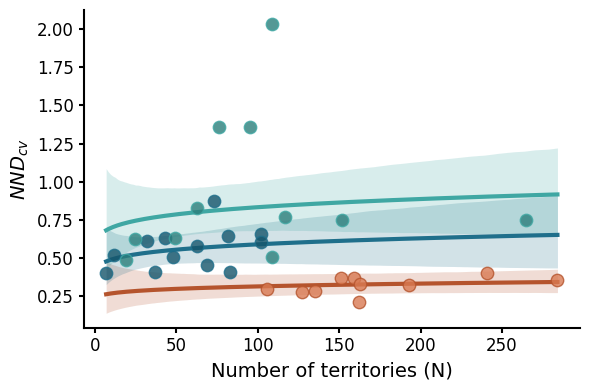

In [36]:
## Plot change in number of territories with time while controlling for NND 
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id, :].reshape(-1, 1) + fit['gamma'].reshape(-1, 1) * logN_grid.reshape(1, -1)
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(N_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(N_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Overlay observed points (raw relationship, not adjusted)
    ax.scatter(df_lek['nnd_count'], df_lek['nnd_cv'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

# Cosmetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Number of territories (N)', fontsize=14)
ax.set_ylabel('$NND_{cv}$', fontsize=14)

plt.tight_layout()
plt.savefig(out_dir/'mod_nnd_cv_nT.png', dpi=300, bbox_inches='tight')

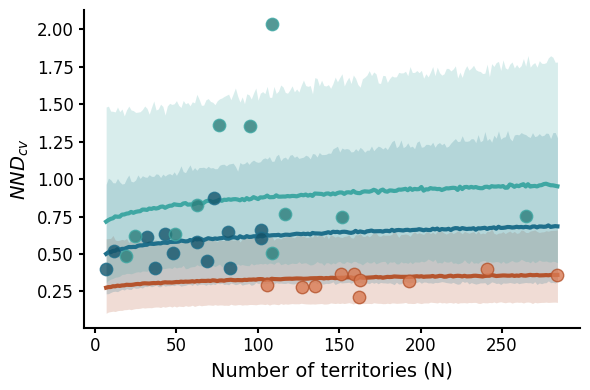

In [37]:
## Plot change in number of territories with time while controlling for NND 
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu_post = fit['alpha'][site_id, :].reshape(-1, 1) + fit['gamma'].reshape(-1, 1) * logN_grid.reshape(1, -1)
    sigma_post = fit['sigma'].reshape(-1,1)
    
    y_post_rep = np.exp(np.random.normal(mu_post, sigma_post))
    y_post_mean = np.mean(y_post_rep, axis=0)
    y_post_lower,y_post_upper = np.quantile(y_post_rep, [0.025,0.975], axis=0)
    
    # Plot model fits
    ax.plot(N_grid, y_post_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(N_grid, y_post_lower, y_post_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Overlay observed points (raw relationship, not adjusted)
    ax.scatter(df_lek['nnd_count'], df_lek['nnd_cv'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

# Cosmetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Number of territories (N)', fontsize=14)
ax.set_ylabel('$NND_{cv}$', fontsize=14)

plt.tight_layout()
plt.savefig(out_dir/'mod_post_nnd_cv_nT.png', dpi=300, bbox_inches='tight')

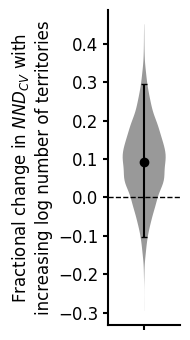

In [38]:
fig, ax = plt.subplots(figsize=(2, 3.5))

# Compute causal effect distribution (fractional yearly change)
yearly_factor = np.exp(fit['gamma'][0, :])
samples = yearly_factor - 1

# Violin plot
parts = ax.violinplot(samples, widths=0.6, showmeans=False, showmedians=False, showextrema=False)

for pc in parts['bodies']:
    pc.set_facecolor('black')
    pc.set_edgecolor('none')
    pc.set_alpha(0.4)

# Overlay median + 95% interval
median = np.median(samples)
lower, upper = np.quantile(samples, [0.025, 0.975])

ax.errorbar(1, median, yerr=[[median-lower], [upper-median]], fmt='o', color='black', markersize=6, capsize=2, zorder=3)

ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_xlim(0.5, 1 + 0.5)
ax.set_xticks([1])
ax.set_xticklabels([])

ax.set_ylabel('Fractional change in $NND_{CV}$ with \nincreasing log number of territories', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'mod_causal_nnd_cv_nT.png', dpi=300, bbox_inches='tight')